# Customer Lifetime Value Predictive Analysis

# 1. Problem Statement

The objective of this project is to develop a predictive analytics model that estimates the future Customer Lifetime Value (CLV) of customers for an e-commerce business. Customer Lifetime Value represents the total revenue a business can expect from a customer throughout their relationship with the company.

Accurately predicting CLV helps businesses identify high-value customers, optimize marketing strategies, improve customer retention, and allocate resources more effectively. By analyzing customer demographics, purchasing behavior, engagement metrics, and transaction history, this project aims to build a regression model capable of predicting each customer's future lifetime value.

The project follows a complete predictive analytics workflow, including exploratory data analysis, data cleaning, feature engineering, model development, evaluation, and business insight generation.

# 2. Dataset Description

- Dataset: Customer-level information collected from an e-commerce platform.
- Records: 25,625 customer records.
- Features: 25 columns, including the target variable.
- Each row represents: One individual customer.
- Target Variable: Future_CLV (predicted future Customer Lifetime Value).
- Objective: Predict Future_CLV using the remaining customer-related features.

### Feature Categories:

- **Customer Information:** Customer ID, Name, Age, Gender, City, State
- **Membership Information:** Membership Level and Acquisition Channel
- **Purchase Behavior:** Total Orders, Total Spend, Average Order Value, Purchase Frequency, Total Items Purchased
- **Customer Engagement:** Website Visits, App Sessions, Days Since Last Purchase
- **Customer Service:** Return Rate, Support Tickets, Customer Satisfaction
- **Payment Information:** Preferred Payment Method
- **Target Variable:** Future_CLV


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [3]:
df = pd.read_csv(r"C:\Users\aswin\OneDrive\Desktop\Predictive-Analytics-Mini-Project\data\ecommerce_clv_dataset.csv")

df.head()

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership_Level,Acquisition_Channel,Customer_Tenure_Days,Total_Orders,Total_Items_Purchased,Total_Spend,Average_Order_Value,Preferred_Category,Website_Visits,App_Sessions,Days_Since_Last_Purchase,Purchase_Frequency_Per_Month,Average_Days_Between_Orders,Coupon_Usage_Rate,Return_Rate,Support_Tickets,Customer_Satisfaction,Preferred_Payment_Method,Future_CLV
0,CUST100000,Madhuri Gupta,22.0,Female,Kolkata,West Bengal,Silver,Organic Search,331,2,3,1805.18,902.59,Sports & Fitness,37.0,27.0,335.0,0.181,168.73,0.478,0.535,3.0,3.27,Debit Card,200.00
1,CUST100001,Ritu Naidu,34.0,Other,Ahmedabad,Gujarat,Silver,Paid Ads,214,3,7,4518.55,1506.18,Home & Kitchen,31.0,20.0,145.0,0.421,67.69,0.392,0.428,2.0,3.64,Credit Card,325.56
2,CUST100002,Vidya Menon,37.0,Female,Hyderabad,Telangana,Silver,Email Marketing,1890,28,79,15672.76,559.74,Grocery,148.0,125.0,87.0,0.444,62.52,0.342,0.229,2.0,3.67,UPI,1201.04
3,CUST100003,Pankaj Pandey,29.0,Male,Delhi,Delhi,Silver,Organic Search,1170,20,37,14660.69,733.03,Fashion,98.0,61.0,27.0,0.513,68.20,0.278,0.421,4.0,3.34,UPI,747.54
4,CUST100004,Pooja Kumar,20.0,Female,Pune,Maharashtra,Silver,Organic Search,360,1,2,303.17,303.17,Electronics,115.0,92.0,398.0,0.083,323.45,0.112,0.266,4.0,3.94,Cash on Delivery,200.00


In [4]:
df.tail()

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership_Level,Acquisition_Channel,Customer_Tenure_Days,Total_Orders,Total_Items_Purchased,Total_Spend,Average_Order_Value,Preferred_Category,Website_Visits,App_Sessions,Days_Since_Last_Purchase,Purchase_Frequency_Per_Month,Average_Days_Between_Orders,Coupon_Usage_Rate,Return_Rate,Support_Tickets,Customer_Satisfaction,Preferred_Payment_Method,Future_CLV
25620,CUST109114,Neha Pandey,27.0,Female,Ahmedabad,Gujarat,Gold,Paid Ads,761,13,33,9256.60,712.05,Electronics,220.0,175.0,9.0,0.512,55.74,0.335,0.226,2.0,4.02,UPI,1341.24
25621,CUST114433,Radhika Thakur,18.0,Female,Bhopal,Madhya Pradesh,Gold,Organic Search,180,3,7,2334.36,778.12,Home & Kitchen,75.0,35.0,74.0,0.500,59.95,0.907,0.194,3.0,4.06,UPI,200.00
25622,CUST108753,Pallavi Pandey,33.0,Female,Hyderabad,Telangana,Silver,Social Media,688,7,17,4247.36,606.77,Fashion,92.0,79.0,75.0,0.305,86.87,0.047,0.463,3.0,3.00,Credit Card,345.93
25623,CUST115547,Arjun Yadav,21.0,Male,Kochi,Kerala,Silver,Social Media,450,2,5,1162.37,581.18,Sports & Fitness,43.0,28.0,269.0,0.133,219.82,0.755,0.388,2.0,3.56,Debit Card,200.00
25624,CUST109372,Karan Bose,36.0,Male,Delhi,Delhi,Silver,Organic Search,578,5,13,2897.36,579.47,Fashion,57.0,42.0,49.0,0.260,137.48,0.582,0.494,1.0,3.14,UPI,284.38


In [5]:
df.sample(5, random_state=42)

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership_Level,Acquisition_Channel,Customer_Tenure_Days,Total_Orders,Total_Items_Purchased,Total_Spend,Average_Order_Value,Preferred_Category,Website_Visits,App_Sessions,Days_Since_Last_Purchase,Purchase_Frequency_Per_Month,Average_Days_Between_Orders,Coupon_Usage_Rate,Return_Rate,Support_Tickets,Customer_Satisfaction,Preferred_Payment_Method,Future_CLV
10297,CUST110297,Manish Singh,37.0,Male,Ahmedabad,Gujarat,Silver,Social Media,819,6,13,3032.30,505.38,Home & Kitchen,79.0,54.0,88.0,0.220,168.88,0.788,0.348,6.0,4.16,UPI,249.93
14045,CUST114045,Siddharth Singh,51.0,Male,Chennai,Tamil Nadu,Platinum,social media,622,15,27,8158.40,543.89,Fashion,55.0,24.0,12.0,0.723,46.71,0.319,0.335,4.0,3.55,UPI,776.97
18337,CUST118337,Anil Verma,44.0,Male,Delhi,Delhi,Silver,Email Marketing,2520,23,44,18427.12,801.18,Beauty & Personal Care,319.0,274.0,160.0,0.274,130.95,0.306,0.191,0.0,4.14,Credit Card,1350.57
22666,CUST122666,Praveen Thakur,27.0,Male,Jaipur,Rajasthan,Platinum,Organic Search,490,7,24,6763.57,966.22,Electronics,96.0,57.0,98.0,0.429,74.26,0.575,0.210,4.0,3.88,Credit Card,798.31
3096,CUST103096,Radhika Bose,42.0,Female,NaN,Maharashtra,Silver,Organic Search,998,3,6,883.11,294.37,Fashion,24.0,15.0,64.0,0.090,283.54,0.520,0.176,0.0,4.24,UPI,200.00


In [6]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 25625
Number of Columns : 25


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25625 entries, 0 to 25624
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer_ID                   25625 non-null  str    
 1   Customer_Name                 25590 non-null  str    
 2   Age                           25591 non-null  float64
 3   Gender                        25584 non-null  str    
 4   City                          25583 non-null  str    
 5   State                         25598 non-null  str    
 6   Membership_Level              25589 non-null  str    
 7   Acquisition_Channel           25589 non-null  str    
 8   Customer_Tenure_Days          25625 non-null  int64  
 9   Total_Orders                  25625 non-null  int64  
 10  Total_Items_Purchased         25625 non-null  int64  
 11  Total_Spend                   25625 non-null  float64
 12  Average_Order_Value           25625 non-null  float64
 13  Preferred_Ca

In [8]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'str']).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Customer_Tenure_Days', 'Total_Orders', 'Total_Items_Purchased', 'Total_Spend', 'Average_Order_Value', 'Website_Visits', 'App_Sessions', 'Days_Since_Last_Purchase', 'Purchase_Frequency_Per_Month', 'Average_Days_Between_Orders', 'Coupon_Usage_Rate', 'Return_Rate', 'Support_Tickets', 'Customer_Satisfaction', 'Future_CLV']

Categorical Features:
['Customer_ID', 'Customer_Name', 'Gender', 'City', 'State', 'Membership_Level', 'Acquisition_Channel', 'Preferred_Category', 'Preferred_Payment_Method']


In [9]:
missing_values = df.isnull().sum()

missing_df = (
    pd.DataFrame({
        "Missing Values": missing_values,
        "Percentage": (missing_values / len(df)) * 100
    })
    .sort_values(by="Missing Values", ascending=False)
)

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percentage
Average_Days_Between_Orders,53,0.206829
Purchase_Frequency_Per_Month,43,0.167805
City,42,0.163902
Gender,41,0.160000
Return_Rate,39,0.152195
Membership_Level,36,0.140488
Acquisition_Channel,36,0.140488
Days_Since_Last_Purchase,35,0.136585
Customer_Name,35,0.136585
Preferred_Category,35,0.136585


In [10]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count}")

Duplicate Rows: 625


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25591.0,32.657419,9.919393,15.00,26.000,32.0000,38.000,79.000
Customer_Tenure_Days,25625.0,966.680702,587.935012,15.00,524.000,900.0000,1350.000,3650.000
Total_Orders,25625.0,13.876722,14.216044,1.00,4.000,9.0000,19.000,155.000
Total_Items_Purchased,25625.0,31.771317,34.581599,1.00,9.000,21.0000,42.000,445.000
Total_Spend,25625.0,10452.529959,14897.566977,251.29,2237.180,5689.9300,12828.540,453410.700
Average_Order_Value,25625.0,700.125145,365.739038,213.59,444.260,616.8100,858.540,5333.230
Website_Visits,25593.0,139.557105,134.726458,2.00,50.000,99.0000,183.000,1722.000
App_Sessions,25601.0,90.651225,91.605669,1.00,31.000,63.0000,118.000,1410.000
Days_Since_Last_Purchase,25590.0,149.947987,188.312571,0.00,32.000,78.0000,182.000,900.000
Purchase_Frequency_Per_Month,25582.0,0.425699,0.300280,0.02,0.205,0.3525,0.564,3.228


In [12]:
df.describe(include='str').T

,count,unique,top,freq
Customer_ID,25625,25000,CUST100127,2
Customer_Name,25590,1800,Praveen Gupta,31
Gender,25584,14,Male,12883
City,25583,96,Delhi,2102
State,25598,58,Maharashtra,3317
Membership_Level,25589,18,Silver,12761
Acquisition_Channel,25589,38,Organic Search,6843
Preferred_Category,25590,43,Electronics,5607
Preferred_Payment_Method,25591,30,UPI,10409


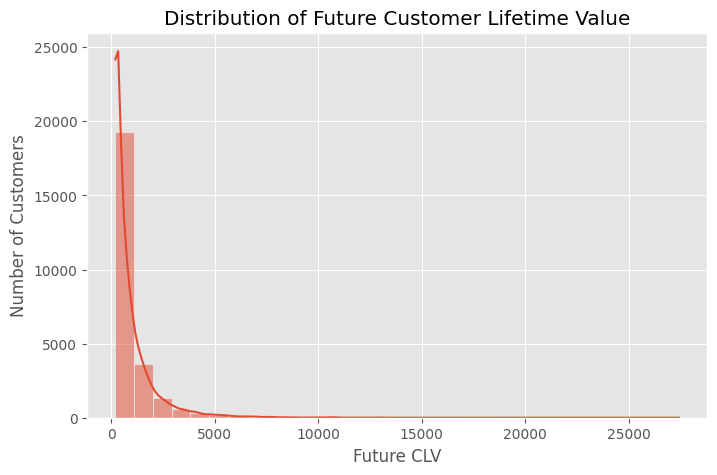

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Future_CLV"], bins=30, kde=True)
plt.title("Distribution of Future Customer Lifetime Value")
plt.xlabel("Future CLV")
plt.ylabel("Number of Customers")

plt.show()

### Observation
- The distribution of **Future_CLV** is **highly right-skewed**.
- Most customers have relatively **low Customer Lifetime Value (CLV)**.
- A small number of customers contribute **exceptionally high lifetime value**.

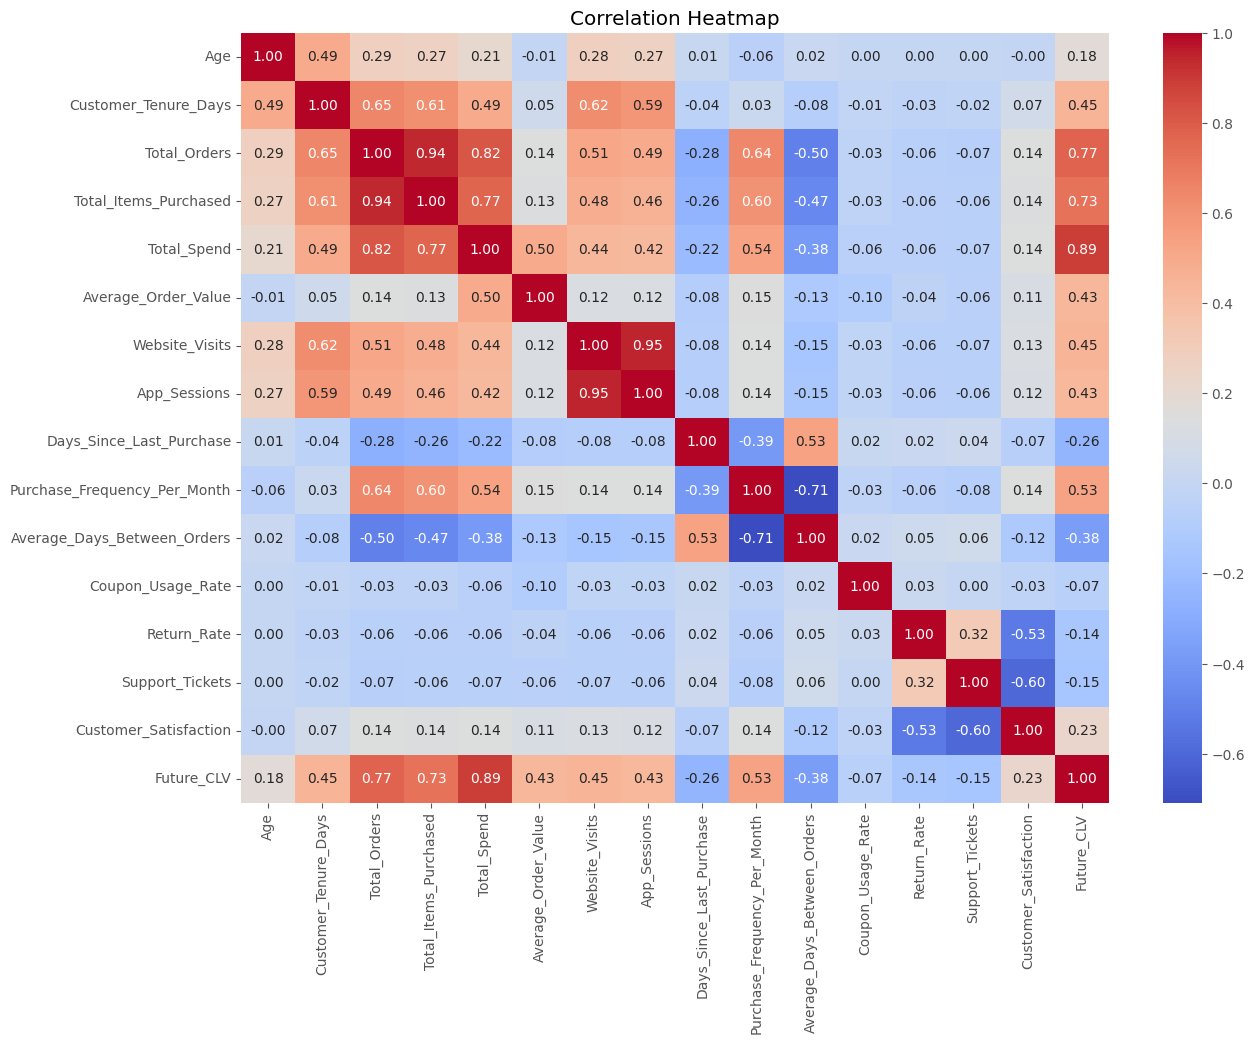

In [14]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df[numerical_features].corr(), annot=True, fmt=".2f", cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation
- **Total Spend**, **Total Orders**, and **Total Items Purchased** show strong positive correlations with **Future_CLV**.
- **Days Since Last Purchase** has a negative correlation with **Future_CLV**.
- Longer intervals between purchases are associated with lower future customer lifetime value.
- Overall, frequent and high-value purchasing behavior is a strong indicator of higher **Future_CLV**.

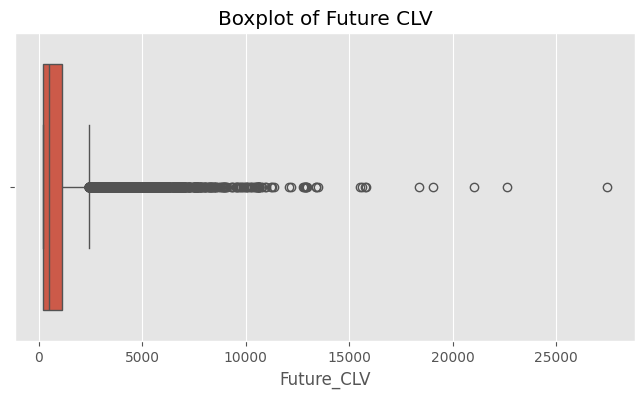

In [15]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Future_CLV"])
plt.title("Boxplot of Future CLV")
plt.show()

### Observaton
- The boxplot reveals several high-value observations in the **Future_CLV** variable.
- These observations likely represent premium or highly loyal customers rather than data entry errors.
- High-value customers are naturally expected in e-commerce datasets.
- Therefore, these observations will be retained and not treated as outliers.

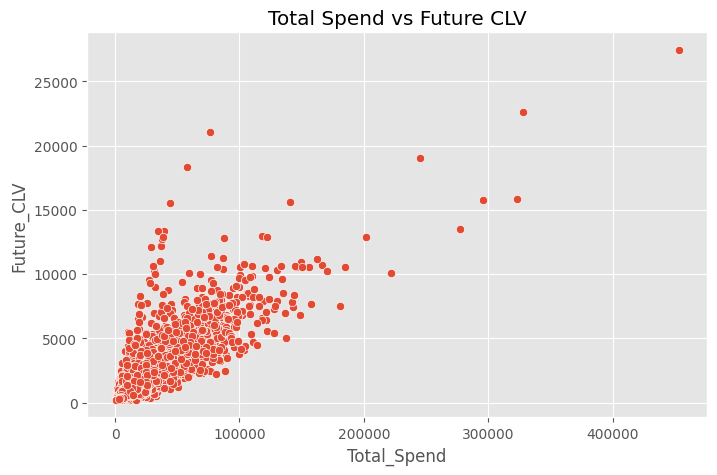

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Total_Spend", y="Future_CLV")
plt.title("Total Spend vs Future CLV")
plt.show()

### Observation
- The scatter plot shows a clear positive relationship between **Total Spend** and **Future_CLV**.
- Customers with higher historical spending generally have higher predicted lifetime value.
- This suggests that **Total Spend** is an important predictor of customer lifetime value.
- The observed relationship indicates that spending behavior can significantly improve model predictions.

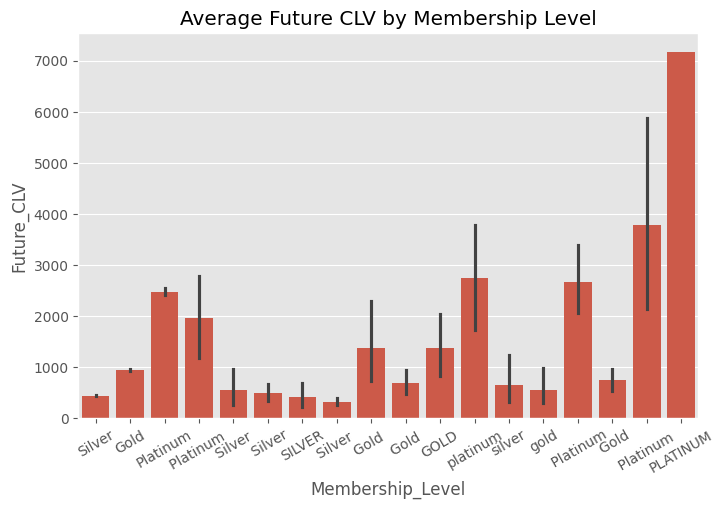

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Membership_Level", y="Future_CLV", estimator=np.mean)
plt.title("Average Future CLV by Membership Level")
plt.xticks(rotation=30)
plt.show()

### Observation
- The average **Future_CLV** varies across different membership levels.
- Some membership categories appear multiple times due to differences in letter casing.
- These duplicate categories indicate inconsistent categorical values in the raw dataset.

## Key Findings from Exploratory Data Analysis
1. The dataset contains 25,625 customer records and 25 features.
2. Both numerical and categorical variables are present.
3. Missing values exist in multiple columns but account for a very small percentage of the dataset.
4. A total of 625 duplicate records were identified.
5. The target variable, Future_CLV, exhibits a right-skewed distribution with a small number of high-value customers.
6. Purchasing behavior features such as Total Spend, Total Orders, and Total Items Purchased show strong positive correlations with Future_CLV.
7. Inconsistent categorical values are visible in certain columns, indicating that data cleaning is necessary before modeling.

# Data Cleaning & Preprocessing
In this section, the dataset is cleaned by identifying and handling missing values, removing duplicate records, correcting inconsistent categorical values, and verifying appropriate data types. These preprocessing steps help ensure the data is accurate, consistent, and suitable for predictive modeling.

In [18]:
df_clean = df.copy()

In [19]:
df_clean.isnull().sum()

Customer_ID                      0
Customer_Name                   35
Age                             34
Gender                          41
City                            42
State                           27
Membership_Level                36
Acquisition_Channel             36
Customer_Tenure_Days             0
Total_Orders                     0
Total_Items_Purchased            0
Total_Spend                      0
Average_Order_Value              0
Preferred_Category              35
Website_Visits                  32
App_Sessions                    24
Days_Since_Last_Purchase        35
Purchase_Frequency_Per_Month    43
Average_Days_Between_Orders     53
Coupon_Usage_Rate               29
Return_Rate                     39
Support_Tickets                 30
Customer_Satisfaction           34
Preferred_Payment_Method        34
Future_CLV                       0
dtype: int64

## Handling Missing Values

In [20]:
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [21]:
categorical_columns = df_clean.select_dtypes(include=["object", "str"]).columns

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [22]:
df_clean.isnull().sum()

Customer_ID                     0
Customer_Name                   0
Age                             0
Gender                          0
City                            0
State                           0
Membership_Level                0
Acquisition_Channel             0
Customer_Tenure_Days            0
Total_Orders                    0
Total_Items_Purchased           0
Total_Spend                     0
Average_Order_Value             0
Preferred_Category              0
Website_Visits                  0
App_Sessions                    0
Days_Since_Last_Purchase        0
Purchase_Frequency_Per_Month    0
Average_Days_Between_Orders     0
Coupon_Usage_Rate               0
Return_Rate                     0
Support_Tickets                 0
Customer_Satisfaction           0
Preferred_Payment_Method        0
Future_CLV                      0
dtype: int64

## Remove Duplicate Records

In [23]:
print("Duplicate Rows:", df_clean.duplicated().sum())

Duplicate Rows: 625


In [24]:
df_clean.drop_duplicates(inplace=True)

print("Duplicate Rows After Cleaning:", df_clean.duplicated().sum())

Duplicate Rows After Cleaning: 0


In [25]:
df_clean.shape

(25000, 25)

## Fix Inconsistent Values

In [26]:
for col in categorical_columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(df_clean[col].unique())


Column: Customer_ID
<StringArray>
['CUST100000', 'CUST100001', 'CUST100002', 'CUST100003', 'CUST100004',
 'CUST100005', 'CUST100006', 'CUST100007', 'CUST100008', 'CUST100009',
 ...
 'CUST124990', 'CUST124991', 'CUST124992', 'CUST124993', 'CUST124994',
 'CUST124995', 'CUST124996', 'CUST124997', 'CUST124998', 'CUST124999']
Length: 25000, dtype: str

Column: Customer_Name
<StringArray>
[ 'Madhuri Gupta',     'Ritu Naidu',    'Vidya Menon',  'Pankaj Pandey',
    'Pooja Kumar',    'Varun Menon',   'Ganesh Verma',  'Pallavi Naidu',
 'Deepika Bansal',    'Kajal Kumar',
 ...
  'Ganesh Thakur',    'Sanjay Nair',      'Ritu Nair',  'Kavita Pillai',
  'Vidya Chauhan',     'Anil Menon',   'Divya Pandey',  'Nandini Patel',
 'Suresh Agarwal',   'Rahul Thakur']
Length: 1800, dtype: str

Column: Gender
<StringArray>
[  'Female',    'Other',     'Male',  ' Female',    ' Male',     'male',
   'FEMALE',   ' Male ',  'Female ',    'Male ', ' Female ',   'female',
  ' Other ',     'MALE']
Length: 14, dtyp

In [27]:
def clean_text(series):
    return (
        series
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
    )

In [28]:
text_columns = [
    "Gender",
    "City",
    "State",
    "Membership_Level",
    "Acquisition_Channel",
    "Preferred_Category"
]

for col in text_columns:
    df_clean[col] = clean_text(df_clean[col])

In [29]:
df_clean["Preferred_Payment_Method"] = (
    df_clean["Preferred_Payment_Method"]
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
)

In [30]:
payment_mapping = {
    "Upi": "UPI",
    "Emi": "EMI"
}

df_clean["Preferred_Payment_Method"] = (
    df_clean["Preferred_Payment_Method"]
        .replace(payment_mapping)
)

In [31]:
for col in categorical_columns:
    print(f"\n{col}")
    print(sorted(df_clean[col].unique()))


Customer_ID
['CUST100000', 'CUST100001', 'CUST100002', 'CUST100003', 'CUST100004', 'CUST100005', 'CUST100006', 'CUST100007', 'CUST100008', 'CUST100009', 'CUST100010', 'CUST100011', 'CUST100012', 'CUST100013', 'CUST100014', 'CUST100015', 'CUST100016', 'CUST100017', 'CUST100018', 'CUST100019', 'CUST100020', 'CUST100021', 'CUST100022', 'CUST100023', 'CUST100024', 'CUST100025', 'CUST100026', 'CUST100027', 'CUST100028', 'CUST100029', 'CUST100030', 'CUST100031', 'CUST100032', 'CUST100033', 'CUST100034', 'CUST100035', 'CUST100036', 'CUST100037', 'CUST100038', 'CUST100039', 'CUST100040', 'CUST100041', 'CUST100042', 'CUST100043', 'CUST100044', 'CUST100045', 'CUST100046', 'CUST100047', 'CUST100048', 'CUST100049', 'CUST100050', 'CUST100051', 'CUST100052', 'CUST100053', 'CUST100054', 'CUST100055', 'CUST100056', 'CUST100057', 'CUST100058', 'CUST100059', 'CUST100060', 'CUST100061', 'CUST100062', 'CUST100063', 'CUST100064', 'CUST100065', 'CUST100066', 'CUST100067', 'CUST100068', 'CUST100069', 'CUST1

## Check Data Types

In [32]:
df_clean.dtypes

Customer_ID                         str
Customer_Name                       str
Age                             float64
Gender                              str
City                                str
State                               str
Membership_Level                    str
Acquisition_Channel                 str
Customer_Tenure_Days              int64
Total_Orders                      int64
Total_Items_Purchased             int64
Total_Spend                     float64
Average_Order_Value             float64
Preferred_Category                  str
Website_Visits                  float64
App_Sessions                    float64
Days_Since_Last_Purchase        float64
Purchase_Frequency_Per_Month    float64
Average_Days_Between_Orders     float64
Coupon_Usage_Rate               float64
Return_Rate                     float64
Support_Tickets                 float64
Customer_Satisfaction           float64
Preferred_Payment_Method            str
Future_CLV                      float64


## Issues Identified in the Dataset

The exploratory analysis revealed several data quality issues that required preprocessing before model development.

The following issues were identified:

- Missing values were present in multiple numerical and categorical features.
- The dataset contained 625 duplicate records.
- Several categorical columns contained inconsistent formatting, including:
  - Leading and trailing spaces
  - Mixed letter casing (uppercase, lowercase, title case)
  - Multiple spaces between words
- The data types of all features were reviewed and found to be appropriate for analysis.

## Feature Engineering

The engineered features created in this project are based on business understanding of customer purchasing patterns and engagement. Each feature is evaluated to determine its relationship with the target variable, **Future_CLV**.

### Feature 1: Purchase Intensity

In [33]:
df_clean["Purchase_Intensity"] = (
    df_clean["Total_Orders"] / df_clean["Customer_Tenure_Days"]
)

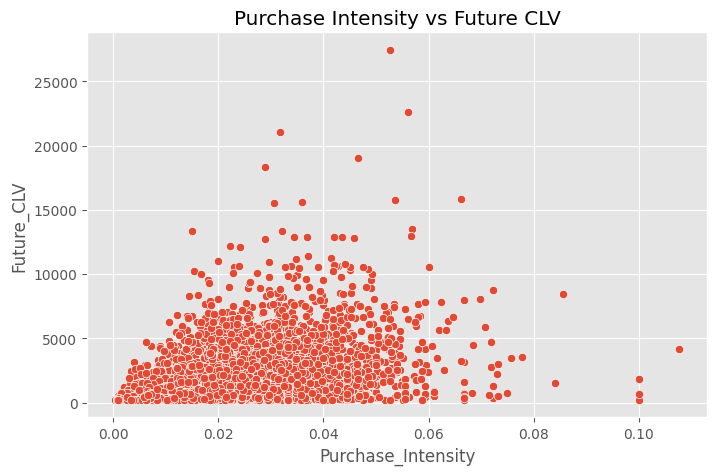

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="Purchase_Intensity", y="Future_CLV")
plt.title("Purchase Intensity vs Future CLV")
plt.show()

- **Purchase Intensity** was created by dividing the **Total Orders** by the **Customer Tenure (days)**.
- It measures how frequently a customer places orders throughout their relationship with the business.
- Customers with higher purchase frequency are generally expected to have a higher lifetime value.
- The feature shows a moderate positive relationship with **Future_CLV**.

### Feature 2: Engagement Score

In [35]:
df_clean["Engagement_Score"] = (
    df_clean["Website_Visits"] + df_clean["App_Sessions"]
)

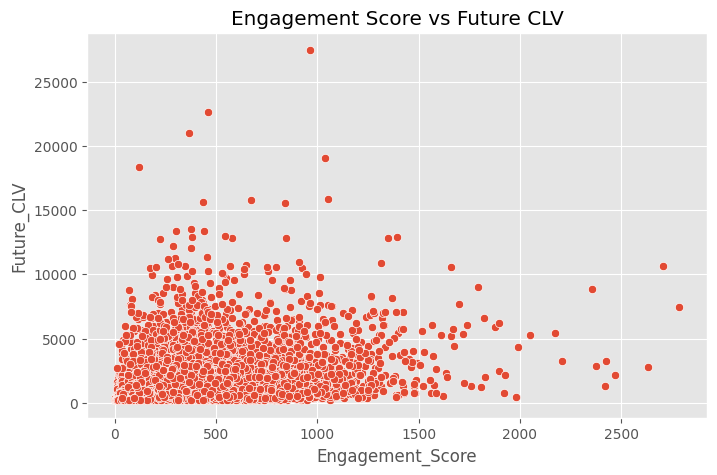

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="Engagement_Score", y="Future_CLV")
plt.title("Engagement Score vs Future CLV")
plt.show()

- **Engagement Score** was created by combining **Website Visits** and **App Sessions**.
- It estimates the overall level of customer interaction with the e-commerce platform.
- Higher engagement generally reflects greater customer interest and a higher likelihood of future purchases.
- The feature shows a moderate positive relationship with **Future_CLV**.

### Feature 3: Spend Per Day

In [37]:
df_clean["Spend_Per_Day"] = (
    df_clean["Total_Spend"] / df_clean["Customer_Tenure_Days"]
)

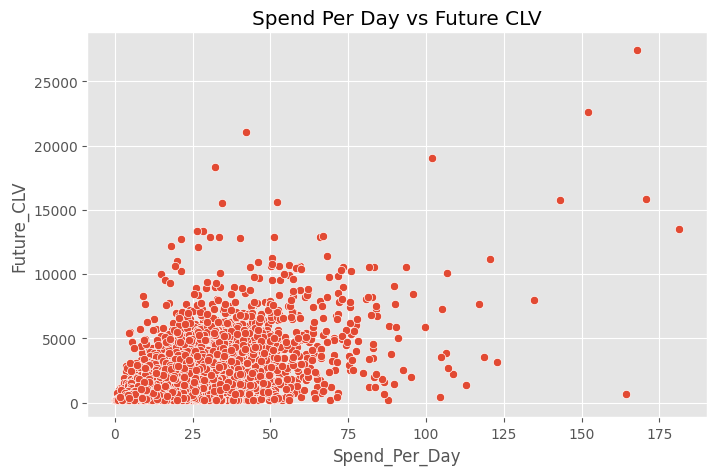

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="Spend_Per_Day", y="Future_CLV")
plt.title("Spend Per Day vs Future CLV")
plt.show()

- **Spend Per Day** was calculated by dividing **Total Spend** by **Customer Tenure (days)**.
- It measures the average amount of revenue a customer generates per day.
- Customers with higher daily spending rates are generally expected to contribute greater lifetime value.
- Among the engineered features, **Spend Per Day** showed the strongest positive relationship with **Future_CLV**.

In [39]:
engineered_features = [
    "Purchase_Intensity",
    "Engagement_Score",
    "Spend_Per_Day",
    "Future_CLV"
]

df_clean[engineered_features].corr()[["Future_CLV"]]

,Future_CLV
Purchase_Intensity,0.529937
Engagement_Score,0.443173
Spend_Per_Day,0.686015
Future_CLV,1.000000


## Feature Engineering Summary

- Three new features were engineered using existing customer purchasing and engagement data.
- The engineered features are:
  - Purchase Intensity
  - Engagement Score
  - Spend Per Day
- Correlation analysis showed that all three features have positive relationships with **Future_CLV**.
- **Spend Per Day** exhibited the strongest positive relationship with **Future_CLV**.
- **Purchase Intensity** showed the second strongest relationship.
- **Engagement Score** also demonstrated a moderate positive relationship.
- These engineered features will be included in the predictive modeling stage to evaluate their impact on model performance.

# Modeling

In [40]:
model_df = df_clean.copy()

In [41]:
X = model_df.drop(columns=["Future_CLV"])
y = model_df["Future_CLV"]

In [42]:
X = X.drop(columns=[
    "Customer_ID",
    "Customer_Name"
])

In [43]:
categorical_cols = X.select_dtypes(include=["object", "str"]).columns

categorical_cols

Index(['Gender', 'City', 'State', 'Membership_Level', 'Acquisition_Channel',
       'Preferred_Category', 'Preferred_Payment_Method'],
      dtype='str')

### One hot encoding

In [44]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [45]:
X.shape

(25000, 83)

### Train-Test Split

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(20000, 83)
(5000, 83)


### Feature Scaling

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Linear Regression

In [48]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

In [49]:
linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
linear_predictions = linear_model.predict(X_test_scaled)

### Ridge Regression

In [55]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

In [56]:
ridge_model.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [57]:
ridge_predictions = ridge_model.predict(X_test_scaled)

### Lasso Regression

In [58]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0, random_state=42)

In [59]:
lasso_model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [60]:
lasso_predictions = lasso_model.predict(X_test_scaled)

In [101]:
selected_features = (lasso_model.coef_ != 0).sum()

removed_features = (lasso_model.coef_ == 0).sum()

print("Selected Features :", selected_features)
print("Removed Features  :", removed_features)

Selected Features : 55
Removed Features  : 28


### Random Forest

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [62]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [63]:
rf_predictions = rf_model.predict(X_test)

### Gradient Boosting

In [64]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [65]:
gbr_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [66]:
gbr_predictions = gbr_model.predict(X_test)

### XGBoost

In [67]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [68]:
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [69]:
xgb_predictions = xgb_model.predict(X_test)

### Evaluation Metrics

In [70]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [71]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = root_mean_squared_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

In [73]:
ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = root_mean_squared_error(y_test, ridge_predictions)
ridge_r2 = r2_score(y_test, ridge_predictions)

In [74]:
lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_rmse = root_mean_squared_error(y_test, lasso_predictions)
lasso_r2 = r2_score(y_test, lasso_predictions)

In [75]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = root_mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

In [76]:
gbr_mae = mean_absolute_error(y_test, gbr_predictions)
gbr_rmse = root_mean_squared_error(y_test, gbr_predictions)
gbr_r2 = r2_score(y_test, gbr_predictions)

In [77]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = root_mean_squared_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

In [99]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        rf_mae,
        gbr_mae,
        xgb_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        gbr_rmse,
        xgb_rmse
    ],
    "R² Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        gbr_r2,
        xgb_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,243.053572,492.581600,0.830567
1,Ridge Regression,243.053520,492.583195,0.830566
2,Lasso Regression,241.686409,492.056945,0.830928
3,Random Forest,200.309244,462.516079,0.850619
4,Gradient Boosting,200.004337,458.293477,0.853334
5,XGBoost,198.522807,454.797930,0.855563


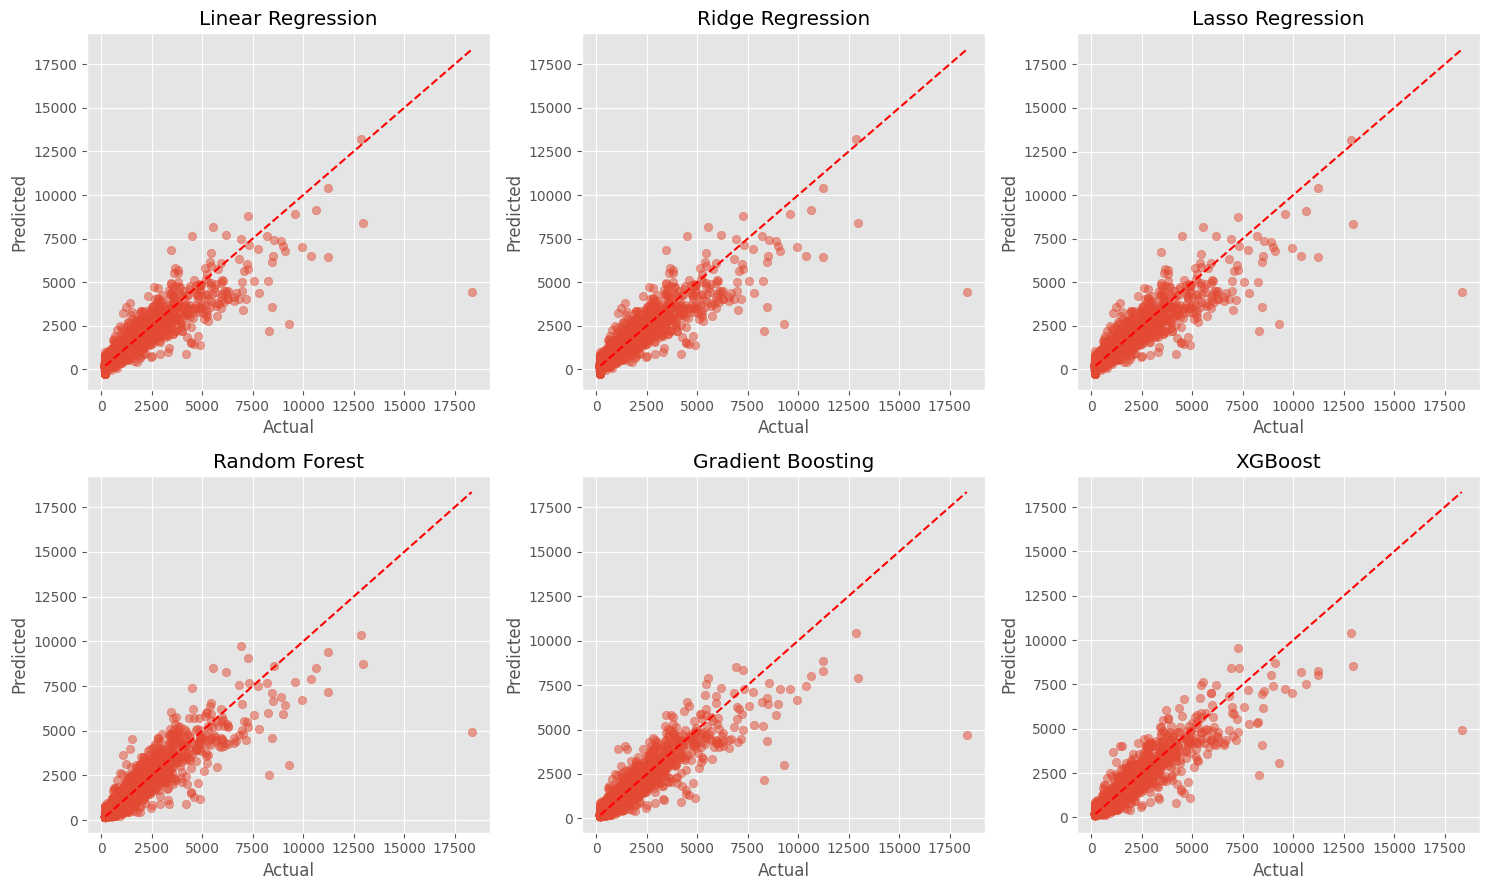

In [100]:
predictions = {
    "Linear Regression": linear_predictions,
    "Ridge Regression": ridge_predictions,
    "Lasso Regression": lasso_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosting": gbr_predictions,
    "XGBoost": xgb_predictions
}

rows = 2
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, predictions.items()):

    ax.scatter(y_test, pred, alpha=0.5)

    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linestyle="--"
    )

    ax.set_title(name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

for ax in axes[len(predictions):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [81]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(15)

,Feature,Importance
4,Total_Spend,0.271201
17,Spend_Per_Day,0.103606
1,Customer_Tenure_Days,0.078301
64,Membership_Level_Platinum,0.074879
2,Total_Orders,0.050139
3,Total_Items_Purchased,0.030764
78,Preferred_Payment_Method_Credit Card,0.023453
61,State_Telangana,0.021848
80,Preferred_Payment_Method_EMI,0.016564
43,City_Noida,0.016487


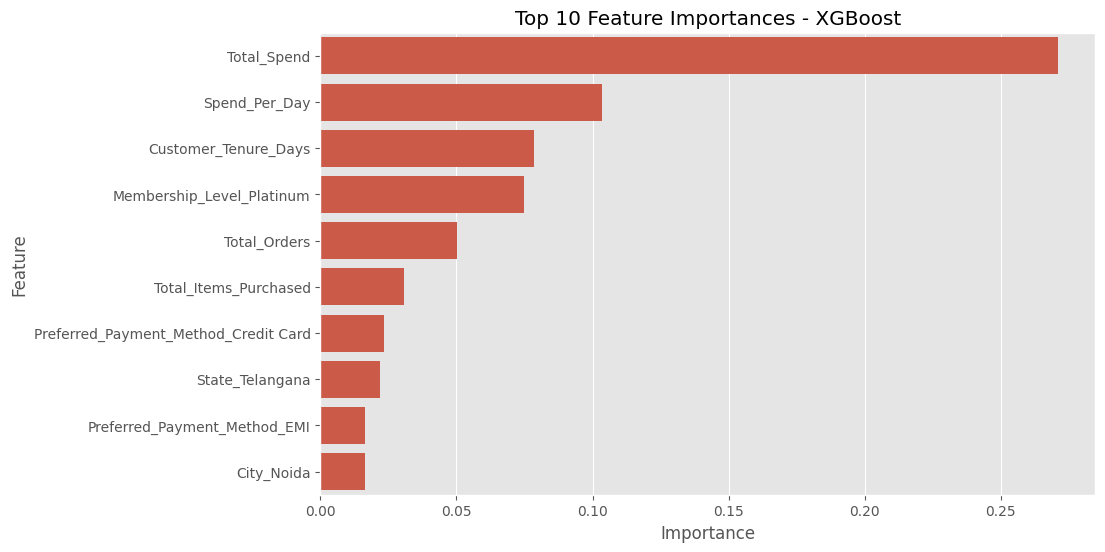

In [104]:
top_xgb = xgb_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(data=top_xgb, x="Importance", y="Feature")
plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Model Selection

- Multiple regression models were evaluated for predicting **Future Customer Lifetime Value (Future_CLV)**.
- The models tested include:
  - Linear Regression
  - Ridge Regression
  - Lasso Regression
  - Random Forest Regressor
  - Gradient Boosting Regressor
  - XGBoost Regressor
- **Linear Regression** was used as the baseline model due to its simplicity and interpretability.
- **Ridge Regression** and **Lasso Regression** were implemented to examine the impact of regularization and feature selection on prediction performance.
- **Random Forest** and **Gradient Boosting** were used to capture complex non-linear relationships and interactions between customer attributes.
- **XGBoost Regressor** was implemented as an advanced boosting algorithm known for its strong predictive performance on structured business datasets.
- Model performance was evaluated using:
  - Mean Absolute Error (MAE)
  - Root Mean Squared Error (RMSE)
  - R² Score
- Among all evaluated models, **XGBoost Regressor achieved the best overall performance**, producing the lowest prediction errors and the highest R² Score.
- Therefore, **XGBoost was selected as the final model for Future_CLV prediction**.

### Interpretation of Model Performance

- Six regression models were evaluated to predict **Future Customer Lifetime Value (Future_CLV)**.
- **Linear Regression** provided a strong baseline performance with an **R² Score of 0.8306**, indicating that it successfully captured the primary linear relationships within the dataset.
- **Ridge Regression** produced nearly identical results to Linear Regression, showing that regularization had minimal impact because the dataset did not suffer from significant multicollinearity.
- **Lasso Regression** achieved a slight improvement in prediction accuracy while also performing feature selection by reducing the influence of less important features.
- **Random Forest Regressor** significantly improved prediction performance by learning non-linear relationships and complex interactions between customer features.
- **Gradient Boosting Regressor** further improved the prediction accuracy by sequentially correcting errors made by previous decision trees.
- **XGBoost Regressor** achieved the best overall performance with the **lowest MAE (198.52)**, **lowest RMSE (454.80)**, and **highest R² Score (0.8556)** among all evaluated models.
- The results indicate that the relationship between customer characteristics and Future_CLV is not purely linear, and advanced ensemble methods are better able to capture these complex patterns.
- Based on the evaluation metrics, **XGBoost Regressor was selected as the final predictive model** because it provided the most accurate and reliable predictions on the test dataset.

### Evaluation Metrics

The regression models were evaluated using:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted values.
- **Root Mean Squared Error (RMSE):** Penalizes larger prediction errors more heavily than MAE.
- **R² Score:** Indicates the proportion of variance in the target variable explained by the model. Higher values indicate better predictive performance.

# Insights

### 1. Total Spend was the strongest predictor of Future Customer Lifetime Value.
- Total_Spend showed the strongest relationship with Future_CLV.
- Customers who spent more historically were more likely to generate higher future value.
- This indicates that past spending behavior is a strong indicator of future customer profitability.

### 2. Purchase Intensity positively influenced Future_CLV.
- The engineered feature **Purchase_Intensity** showed a moderate positive correlation (≈ 0.53) with Future_CLV.
- Customers who purchased more frequently relative to their tenure tended to have higher lifetime value.
- This feature helped capture customer purchasing behavior more effectively.

### 3. Spend Per Day was one of the most valuable engineered features.
- **Spend_Per_Day** showed a strong positive correlation (≈ 0.69) with Future_CLV.
- Customers with higher average daily spending generally had higher predicted lifetime value.
- This engineered feature improved the model's ability to identify high-value customers.

### 4. Customer engagement positively affected Future_CLV.
- The **Engagement_Score** feature demonstrated a moderate positive relationship with Future_CLV.
- Customers with more website visits and app sessions generally generated higher future value.
- Higher engagement reflects stronger customer interest and retention.

### 5. Membership level influenced customer value.
- Premium membership levels, particularly **Platinum**, had higher average Future_CLV than lower membership tiers.
- Loyalty programs appear to encourage greater customer spending over time.
- Membership level can be used to identify high-value customer segments.

### 6. Customer satisfaction contributed to higher Future_CLV.
- Customers with higher satisfaction scores generally achieved higher predicted lifetime values.
- Positive customer experiences can contribute to stronger long-term customer relationships.
- Improving customer satisfaction may help increase future revenue.

### 7. Purchase recency and frequency impacted customer value.
- Customers with fewer days since their last purchase generally had higher Future_CLV.
- Longer intervals between purchases were associated with lower customer value.
- Frequent purchasing behavior is an important indicator of customer retention.

### 8. Ensemble models outperformed linear models.
- Linear Regression provided a strong baseline with an R² Score of approximately 0.83.
- Random Forest, Gradient Boosting, and XGBoost captured more complex relationships within the data.
- Tree-based ensemble models produced more accurate predictions than linear models.

### 9. XGBoost achieved the best predictive performance.
- XGBoost produced the lowest MAE (198.52) and RMSE (454.80).
- It achieved the highest R² Score (0.8556) among all evaluated models.
- Therefore, XGBoost was selected as the final predictive model for this project.

### 10. Data preprocessing and feature engineering improved model performance.
- Handling missing values, duplicate records, and inconsistent categorical values improved overall data quality.
- Creating meaningful engineered features provided additional predictive information.
- Proper preprocessing contributed to better model accuracy and more reliable predictions.

# Conclusion

- A complete predictive analytics workflow was developed to estimate **Future_CLV** using customer demographic, behavioral, and transactional data.
- The project included:
  - Exploratory Data Analysis (EDA)
  - Data Cleaning
  - Feature Engineering
  - Regression Modeling
  - Business Insight Interpretation
- **XGBoost Regressor** achieved the best predictive performance with an **R² score of approximately 0.85**.
- Feature engineering improved the analysis by introducing:
  - Purchase Intensity
  - Engagement Score
  - Spend Per Day
- The analysis identified **customer spending behavior**, **purchase frequency**, **membership level**, and **customer engagement** as key factors influencing **Future_CLV**.
- The findings can help businesses:
  - Identify high-value customers
  - Improve customer retention strategies
  - Optimize marketing efforts
  - Support data-driven business decision-making

## Limitations

- The dataset is synthetic and may not fully represent real-world customer behavior.
- External factors such as market trends, seasonal demand, and competitor activities were not included in the analysis.
- The model predictions are based only on the available features and may improve with additional customer or marketing data.
- Hyperparameter tuning was limited, so further optimization may improve the performance of the machine learning models.
- The analysis was performed on a single dataset, and the model was not validated using data from different businesses or industries.

## Possible Improvements

- Collect real-world customer data to improve the model's reliability and practical applicability.
- Perform hyperparameter tuning to further improve the performance of the machine learning models.
- Include additional features such as customer demographics, marketing campaigns, and seasonal trends to enhance prediction accuracy.
- Evaluate more advanced machine learning models and compare their performance using cross-validation.
- Apply feature selection techniques to reduce redundant variables before modeling.

In [105]:
import joblib

joblib.dump(xgb_model, "../models/xgboost_model.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [106]:
import joblib

joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [107]:
import joblib

categorical_columns = [
    "Gender",
    "City",
    "State",
    "Membership_Level",
    "Acquisition_Channel",
    "Preferred_Category",
    "Preferred_Payment_Method"
]

joblib.dump(
    categorical_columns,
    "../models/categorical_columns.pkl"
)

['../models/categorical_columns.pkl']

In [109]:
print(sorted(df_clean["Gender"].unique()))
print(sorted(df_clean["Membership_Level"].unique()))
print(sorted(df_clean["Acquisition_Channel"].unique()))
print(sorted(df_clean["Preferred_Category"].unique()))
print(sorted(df_clean["Preferred_Payment_Method"].unique()))
print(sorted(df_clean["State"].unique()))
print(sorted(df_clean["City"].unique()))

['Female', 'Male', 'Other']
['Gold', 'Platinum', 'Silver']
['Affiliate', 'Email Marketing', 'Organic Search', 'Paid Ads', 'Referral', 'Social Media']
['Beauty & Personal Care', 'Books', 'Electronics', 'Fashion', 'Grocery', 'Home & Kitchen', 'Mobile & Accessories', 'Sports & Fitness']
['Cash On Delivery', 'Credit Card', 'Debit Card', 'EMI', 'Net Banking', 'UPI']
['Assam', 'Bihar', 'Delhi', 'Gujarat', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']
['Ahmedabad', 'Bengaluru', 'Bhopal', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Guwahati', 'Howrah', 'Hubballi', 'Hyderabad', 'Indore', 'Jaipur', 'Jodhpur', 'Kanpur', 'Kochi', 'Kolkata', 'Kozhikode', 'Lucknow', 'Ludhiana', 'Madurai', 'Mumbai', 'Mysuru', 'Nagpur', 'Noida', 'Patna', 'Pune', 'Surat', 'Thiruvananthapuram', 'Udaipur', 'Vadodara', 'Warangal']


In [110]:
import joblib

feature_columns = joblib.load("../models/feature_columns.pkl")

print(len(feature_columns))
print(feature_columns)

83
['Age', 'Customer_Tenure_Days', 'Total_Orders', 'Total_Items_Purchased', 'Total_Spend', 'Average_Order_Value', 'Website_Visits', 'App_Sessions', 'Days_Since_Last_Purchase', 'Purchase_Frequency_Per_Month', 'Average_Days_Between_Orders', 'Coupon_Usage_Rate', 'Return_Rate', 'Support_Tickets', 'Customer_Satisfaction', 'Purchase_Intensity', 'Engagement_Score', 'Spend_Per_Day', 'Gender_Male', 'Gender_Other', 'City_Bengaluru', 'City_Bhopal', 'City_Chandigarh', 'City_Chennai', 'City_Coimbatore', 'City_Delhi', 'City_Guwahati', 'City_Howrah', 'City_Hubballi', 'City_Hyderabad', 'City_Indore', 'City_Jaipur', 'City_Jodhpur', 'City_Kanpur', 'City_Kochi', 'City_Kolkata', 'City_Kozhikode', 'City_Lucknow', 'City_Ludhiana', 'City_Madurai', 'City_Mumbai', 'City_Mysuru', 'City_Nagpur', 'City_Noida', 'City_Patna', 'City_Pune', 'City_Surat', 'City_Thiruvananthapuram', 'City_Udaipur', 'City_Vadodara', 'City_Warangal', 'State_Bihar', 'State_Delhi', 'State_Gujarat', 'State_Karnataka', 'State_Kerala', 'State